In [1]:
"""
Self-RAG

- 생성한 답변을 검증한다
- 생성한 답변이 문서를 기반으로 했는지 검증을 한다
    - 그렇지 않으면 다시 생성
    - 그러한 경우에는 생성한 답변이 질문과 관련이 있는지 검증
        - 관련이 있으면 END
        - 그렇지 않은 경우에 rewrite를 해서 다시 retrieve를 해서 전체적인 사이클을 돌린다.

-------------------------------------------------------------

[핵심]
- 에이전트가 자체적으로 본인을 돌아보는 것 (자가검증)
    - 답변의 퀄리티 제고
    - 사용자가 원하는 질문에 답변을 한건지 검증
"""

'\nSelf-RAG\n\n- 생성한 답변을 검증한다\n- 생성한 답변이 문서를 기반으로 했는지 검증을 한다\n    - 그렇지 않으면 다시 생성\n    - 그러한 경우에는 생성한 답변이 질문과 관련이 있는지 검증\n        - 관련이 있으면 END\n        - 그렇지 않은 경우에 rewrite를 해서 다시 retrieve를 해서 전체적인 사이클을 돌린다.\n\n-------------------------------------------------------------\n\n[핵심]\n- 에이전트가 자체적으로 본인을 돌아보는 것 (자가검증)\n    - 답변의 퀄리티 제고\n    - 사용자가 원하는 질문에 답변을 한건지 검증\n'

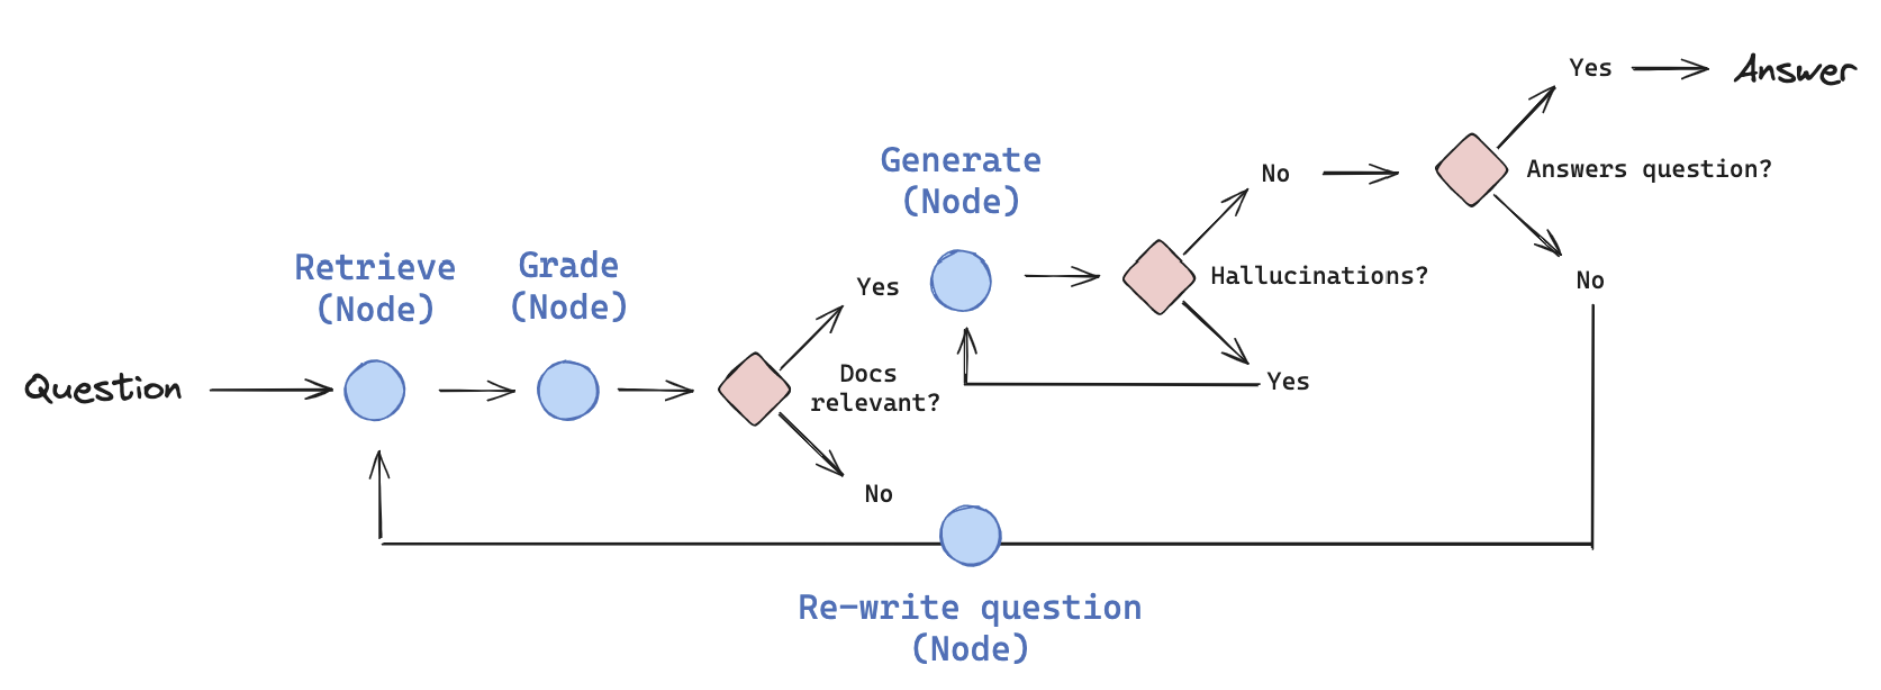

In [2]:
# DB 접근
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings


# 이제 임베딩 생성에는 OPENAI_API_KEY도 필요 없고 API 비용 발생 X
embedding_function = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

# 이미 생성된 db 에서 조회하는 코드 (Chroma 클래스를 바로 활용한다  )
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='../income_tax_collection'   # 로컬에 설정한 경로로 데이터가 남음 (DB의 역할을 한다)
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [3]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str
    
graph_builder = StateGraph(AgentState)

In [4]:
# retrieve 노드는 사용자의 질문을 받아 벡터 스토어에서 추출한 데이터를 반환한다

def retrieve(state: AgentState):
    query = state["query"]  # state 에서 query 를 꺼내온다.
    
    docs = retriever.invoke(query)  # 검색한 문서

    # 검색한 문서를 state의 context 에 넣어준다 (docs를 담아준다)
    return {'context': docs}  # 여기서 키값 (context)은 앞서서 state를 선언한 이름과 동일해야 함

In [5]:
from langchain_ollama import ChatOllama

# LLM 선언

# 추후에 num_ctx, num_predict 등 다른 인자 제외하고 테스트 해볼 것
llm = ChatOllama(
    model='exaone3.5:7.8b',
    # temperature=0,
    # reasoning=False,  # 긴 내부 추론을 끔
    # num_ctx=8192,  # 입력과 출력을 합친 컨텍스트 한도를 늘림
)

In [6]:
from langchain_classic import hub
from langsmith import Client

client = Client()

In [7]:
generate_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
    )

# 디버깅 이후
generate_llm = ChatOllama(
    model='exaone3.5:7.8b', 
    num_predict=512,  # 생성할 최대 토큰 수
)

def generate(state:AgentState):
    context = state['context']
    query = state['query']

    rag_chain = generate_prompt | generate_llm  # 디버깅 이후

    # Langsmith 공식문서에 보면, question과 context를 인자로 받는다
    response = rag_chain.invoke({'question': query, 'context': context})  

    # response 를 return
    # return {'answer': response}

    return {'answer': response.content}   # 디버깅 후

# 프롬프트를 기반으로 LLM을 호출한다.

In [8]:
# Langsmith의 프롬프트 활용 - 노션 참고
from typing import Literal

doc_relevance_prompt = client.pull_prompt(
    "langchain-ai/rag-document-relevance",
    dangerously_pull_public_prompt=True,
)

"""
check_doc_relevance 노드의 반환값을 아래와 같이 로 하게될 경우, 에러가 난다

    ```
    return 'END'
    ```

    END는 노드가 아니라서 Literal로 넘겨줘도 작동을 하지 않는다. -> 엣지 추가 시점에서 작업을 진행해줘야 함
    'relevant' 와 'irrelevant' 노드를 return 하는 걸로 대체
"""

def check_doc_relevance(state:AgentState) -> Literal["relevant", "irrelevant"]:
    context = state['context']
    query = state['query']

    print(f'context== {context}')

    doc_relevance_chain = doc_relevance_prompt | llm

    response = doc_relevance_chain.invoke({'question': query, 'documents': context})  
    print(f'response== {response}')
  
    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'   

In [9]:
# 프롬프트 작성 (PromptTemplate 활용)

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


dictionary = ['사람과 관련된 표현 -> 거주자']  # dictionary 선언

rewrite_prompt = PromptTemplate.from_template(
    f""" 사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    사전: {dictionary}
    질문: {{query}}
    """
)

def rewrite(state:AgentState):
    query = state['query']

    rewrite_chain = rewrite_prompt | llm | StrOutputParser()   # 체이닝

    response = rewrite_chain.invoke({'query': query})  

    return {'query': response}

- 새로운 노드 생성

In [10]:
# # 할루시네이션 노드 검증 생성

# hallucination_prompt = client.pull_prompt(
#     "langchain-ai/rag-answer-hallucination",
#     dangerously_pull_public_prompt=True,
# )


# def check_hallucination(state:AgentState):

#     answer = state['answer']   # 답변을 봐야함
#     context = state['context']   

#     print(f'answer === {answer}')

#     hallucination_chain = hallucination_prompt | llm 
#     response = hallucination_chain.invoke({'student_answer': answer, 'documents':context})   # 공식문서: student_answer, documents 를 대입해야 함

#     print(f'hallucination response === {response}')

#     # 올바른 답변 생성 
#     if response['Score'] == 1:
#         return 'generate'
    
#     return 'end'  # 잘못된 답변 생성



In [ ]:
## 디버깅 이후
from langchain_core.prompts import PromptTemplate

# 페르소나를 제공
# hallucination 이 어떤 건지에 대한 정보 제공 
hallucination_prompt = PromptTemplate.from_template("""
You are a teacher tasked with evaluating whether a student's answer is based on documents or not,
Given documents, which are excerpts from income tax law, and a student's answer;
If the student's answer is based on documents, respond with "not hallucinated",
If the student's answer is not based on documents, respond with "hallucinated".

documents: {documents}
student_answer: {student_answer}

""")


hallucination_llm = ChatOllama(
    model='exaone3.5:7.8b', 
    temperature=0
)

def check_hallucination(state:AgentState) -> Literal['hallucinated', 'not hallucinated']:

    answer = state['answer']   # 답변을 봐야함
    context = state['context']   
    context = [doc.page_content for doc in context]  # 디버깅 이후
    print(f'answer === {answer}')

    hallucination_chain = hallucination_prompt | hallucination_llm | StrOutputParser()  # 디버깅 후
    response = hallucination_chain.invoke({'student_answer': answer, 'documents':context})   # 공식문서: student_answer, documents 를 대입해야 함

    print(f'hallucination response === {response}')

    return response


In [12]:
query = "연봉 5천만원인 거주자의 소득세는 얼마인가요?"
context = retriever.invoke(query)  # invoke 한 값

print("document")
for document in context:
    print(document.page_content)
print("document")

generate_state = {
    "query": query,
    "context": context,
}

answer = generate(generate_state)
print(f"answer == {answer}")

hallucination_state = {
    "answer": answer,
    "context": context,
}

check_hallucination(hallucination_state)


# 문서는 잘 들어간 것까지 확인
# 단, 생성된 답변이 잘못됨 (624만원이라고 찍혀야 됨) -> generate 노드가 출력됨

document
| 1,400만원 이하               | 16퍼센트                                                            |
| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |
| 5,000만원 이하               |                                                                     |
| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |
| 8,800만원 이하               |                                                                     |
| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |
| 1억5천만원 이하               |                                                                     |
| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |
| 3억원 이하                   |                                                                     |
| 3억원 초과                   | 1억2,406만원 + (3억원 초과액 × 50퍼센트)                                 |
| 5억원 이하                   |       

AIMessage(content='not hallucinated', additional_kwargs={}, response_metadata={'model': 'exaone3.5:7.8b', 'created_at': '2026-10-04T07:54:49.0664656Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4353308500, 'load_duration': 7115400, 'prompt_eval_count': 2376, 'prompt_eval_duration': 3427751000, 'eval_count': 4, 'eval_duration': 698438000, 'logprobs': None, 'model_name': 'exaone3.5:7.8b', 'model_provider': 'ollama'}, id='lc_run--01a105e8-7c67-7ef3-a941-0f622a46de25-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2376, 'output_tokens': 4, 'total_tokens': 2380})

In [13]:
## 번외

# answer == {'answer': AIMessage(content='연봉 5천만원인 경우, 소득세는 224만원에 (5천만원 초과액 × 25%) 계산됩니다. 정확한 금액은 초과액에 따라 달라지지만, 기본 공제 후 적용 세율 기준으로는 이 범위 내에 있습니다. 정확한 수치를 위해서는 초과액을 고려한 세부 계산이 필요합니다.', additional_kwargs={}, response_metadata={'model': 'exaone3.5:7.8b', 'created_at': '2026-10-04T05:37:49.7086719Z', 'done': True, 'done_reason': 'stop', 'total_duration': 116198840200, 'load_duration': 9032170800, 'prompt_eval_count': 2470, 'prompt_eval_duration': 92467175000, 'eval_count': 79, 'eval_duration': 14651242000, 'logprobs': None, 'model_name': 'exaone3.5:7.8b', 'model_provider': 'ollama'}, id='lc_run--01a10569-5ca3-73e3-833f-35ba02d80d63-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2470, 'output_tokens': 79, 'total_tokens': 2549})}
# answer === {'answer': AIMessage(content='연봉 5천만원인 경우, 소득세는 224만원에 (5천만원 초과액 × 25%) 계산됩니다. 정확한 금액은 초과액에 따라 달라지지만, 기본 공제 후 적용 세율 기준으로는 이 범위 내에 있습니다. 정확한 수치를 위해서는 초과액을 고려한 세부 계산이 필요합니다.', additional_kwargs={}, response_metadata={'model': 'exaone3.5:7.8b', 'created_at': '2026-10-04T05:37:49.7086719Z', 'done': True, 'done_reason': 'stop', 'total_duration': 116198840200, 'load_duration': 9032170800, 'prompt_eval_count': 2470, 'prompt_eval_duration': 92467175000, 'eval_count': 79, 'eval_duration': 14651242000, 'logprobs': None, 'model_name': 'exaone3.5:7.8b', 'model_provider': 'ollama'}, id='lc_run--01a10569-5ca3-73e3-833f-35ba02d80d63-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2470, 'output_tokens': 79, 'total_tokens': 2549})}
# hallucination response === {'Score': 1 ... }

# 답변은 잘 생성이 되었는데 (624만원...), hallucination response === Score : 0 으로 찍힌 케이스가 있을 수 있음
## 랭체인에서 제공하는 프롬프트가 정상적으로 동작하지 않는 것
### 아니면 답변이 너무 길기 때문일 수도 있다.

# 위와 같은 케이스에서는 두가지를 시도해볼 수 있다
# 1. generate의 체인을 수정해서 답변의 길이를 짧게 나오게 하는 방법
# 2. hallucination 프롬프트를 직접 작성 (PromptTemplate) - 


# 디버깅 과정
# 2번의 방법을 진행해봤으나, 그런데도 계속해서 hallucinated 라고 나온다 -> generate 노드의 response 에서 content만 추출해본다
## answer 에는 ai 답변만 들어가있는게 아니라 AIMessage 객체가 들어간다 -> 포맷을 수정
### 1. return 하는 메시지의 값은 Basemessage이기 때문에 .content로 수정 -> answer가 string 으로 나온다
### 2. context를 수정 (context = [doc.page_content for doc in context]  # 추가) context 역시 string 만 넣도록 수정
## prompt 를 facts 가 아닌 documents로 수정 
## rag 체인에서 답변의 수를 제한해봐야 한다. generate_llm 을 추가로 선언하여 max_tokens를 지정해준 LLM을 활용해봐야 한다

# not hallucinated 라고 잘 나온다. 

# 보완
# hallucination 은 일관성이 매우 중요한 부분 -> hallucination_llm 에서 temperature를 정의한다

# 해결

- 사용자의 질문과 관련이 있는가

In [ ]:
# LangChain 허브에서 유용성 프롬프트를 가져온다
helpfulness_prompt = client.pull_prompt(
    "langchain-ai/rag-answer-helpfulness",
    dangerously_pull_public_prompt=True
    )

def check_helpfulness_grader(state: AgentState):
    # state에서 질문과 답변을 추출
    query = state['query'] 
    answer = state['answer']
    
    # 답변의 유용성을 평가하기 위한 체인을 생성합니다
    helpfulness_chain = helpfulness_prompt | llm

    response = helpfulness_chain.invoke({'question':query, 'student_answer':answer})
    print(f"response == {response}")

    if response['Score'] == 1:
        return 'helpful'

    return 'unhelpful'


def check_helpfulness(state: AgentState):   # 디버깅
    return state

In [ ]:
# check_helpfulness_grader 노드 검증 
query = "연봉 5천만원인 거주자의 소득세는 얼마인가요?"
context = retriever.invoke(query)  # invoke 한 값

print("document")
for document in context:
    print(document.page_content)
print("document")

generate_state = {
    "query": query,
    "context": context,
}

answer = generate(generate_state)
print(f"answer == {answer}")

helpfulness_state = {
    "query": query,
    "answer": answer,
}

check_helpfulness(helpfulness_state)

document
| 1,400만원 이하               | 16퍼센트                                                            |
| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |
| 5,000만원 이하               |                                                                     |
| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |
| 8,800만원 이하               |                                                                     |
| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |
| 1억5천만원 이하               |                                                                     |
| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |
| 3억원 이하                   |                                                                     |
| 3억원 초과                   | 1억2,406만원 + (3억원 초과액 × 50퍼센트)                                 |
| 5억원 이하                   |       

'helpful'

##### 그래프 빌드

In [16]:
# 일단 생성한 노드를 모두 다 추가를 해놓고, 그 이후에 동떨어진 노드를 삭제 (주석)
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
# graph_builder.add_node('check_doc_relevance', check_doc_relevance)
graph_builder.add_node('rewrite', rewrite)
# graph_builder.add_node('check_hallucination', check_hallucination)
graph_builder.add_node('check_helpfulness', check_helpfulness)

In [ ]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')

# retrieve 가 들어오면 check_doc_relevance 
# relevant -> generate 노드로 
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': END
    }
)

graph_builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
        'not hallucinated': 'check_helpfulness',
        'hallucinated': 'generate'   # hallucination 이면 답변을 다시 생성해야 함
    }
)


graph_builder.add_conditional_edges(
    'check_helpfulness',
    # check_helpfulness,
    check_helpfulness_grader,
    {
        'helpful': END,
        'unhelpful': 'rewrite'
    }
)

graph_builder.add_edge('rewrite', 'retrieve')

In [18]:
graph = graph_builder.compile()

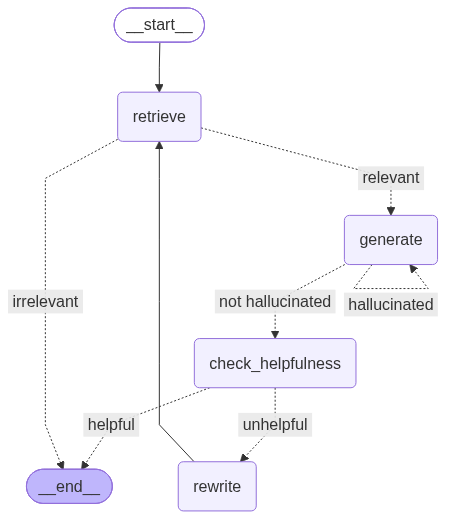

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

- initial_state

In [20]:
# 에러케이스 확인 - 문서와 관련이 없기 때문에 끝난다
error_initial_state = {'query': '배가 고파요'}
graph.invoke(error_initial_state)

context== [Document(id='19806632-2572-4e57-89f3-92030fd34e7d', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='[본조신설 2019. 12. 31.]\n[제목개정 2021. 3. 16.]\n[시행일: 2024. 1. 1.] 제1항1호가1)제1항1호나목(제164조의3제1항1호의 소득에 대한 간이지급명세서를 제출하지 아니한 경우는 제외한다), 제1호2)제1항제2호, 제1호4)제1항(제164조의3제1항1호의 소득에 관한 부분은 제외한다), 제1호2)제15항의 개정규정 중 제164조의3제1항제3호 2 소득에 대한 개정부분\n[시행일: 2026. 1. 1.] 제1항1호가1)제1항1호나목(제164조의3제1항1호의 소득에 대한 간이지급명세서를 제출하지 아니한 경우로 한정한다), 제1호2)제1항제1호, 제1호4)제1항(제164조의3제1항1호의 소득에 관한 부분으로 한정한다)\n법제처 58 국가법령정보센터\n소득세법\n제81조의2(주택임대사업자 미등록 가산세) ① 주택임대소득이 있는 사업자가 제168조제1항 및 제3항에 따라 「부가가치세법」 제8조제1항 본문에 따른 기한까지 등록을 신청하지 아니한 경우에는 사업 개시일부터 등록을 신청한 날의 직전일까지의 주택임대수입금액의 1천분의 2를 가산세로 해당 과세기간 종합소득 결정세액에 더하여 납부하여야 한다.\n② 제1항에 따른 가산세는 종합소득산출세액이 없는 경우에도 적용한다.\n[본조신설 2019. 12. 31.]\n제81조의3(특정외국납입의 유보소득 계산 명세서 제출 불성실 가산세) ① 「국제조세조정에 관한 법률」 제34조제3호에 따른 특정외국법인의 유보소득 계산 명세서(이하 "명세서"라 한다)를 같은 조에 따라 제출하여야 하는 거주자가 다음 각 호의 어느 하나에 해당하는 경우에는 해당 특정외국법인의 배당 가능한 유보소득금액의 1천분의 5를 가산세로 해당 과세기간의 종합소득 결정세액에 더하여

{'query': '배가 고파요',
 'context': [Document(id='19806632-2572-4e57-89f3-92030fd34e7d', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='[본조신설 2019. 12. 31.]\n[제목개정 2021. 3. 16.]\n[시행일: 2024. 1. 1.] 제1항1호가1)제1항1호나목(제164조의3제1항1호의 소득에 대한 간이지급명세서를 제출하지 아니한 경우는 제외한다), 제1호2)제1항제2호, 제1호4)제1항(제164조의3제1항1호의 소득에 관한 부분은 제외한다), 제1호2)제15항의 개정규정 중 제164조의3제1항제3호 2 소득에 대한 개정부분\n[시행일: 2026. 1. 1.] 제1항1호가1)제1항1호나목(제164조의3제1항1호의 소득에 대한 간이지급명세서를 제출하지 아니한 경우로 한정한다), 제1호2)제1항제1호, 제1호4)제1항(제164조의3제1항1호의 소득에 관한 부분으로 한정한다)\n법제처 58 국가법령정보센터\n소득세법\n제81조의2(주택임대사업자 미등록 가산세) ① 주택임대소득이 있는 사업자가 제168조제1항 및 제3항에 따라 「부가가치세법」 제8조제1항 본문에 따른 기한까지 등록을 신청하지 아니한 경우에는 사업 개시일부터 등록을 신청한 날의 직전일까지의 주택임대수입금액의 1천분의 2를 가산세로 해당 과세기간 종합소득 결정세액에 더하여 납부하여야 한다.\n② 제1항에 따른 가산세는 종합소득산출세액이 없는 경우에도 적용한다.\n[본조신설 2019. 12. 31.]\n제81조의3(특정외국납입의 유보소득 계산 명세서 제출 불성실 가산세) ① 「국제조세조정에 관한 법률」 제34조제3호에 따른 특정외국법인의 유보소득 계산 명세서(이하 "명세서"라 한다)를 같은 조에 따라 제출하여야 하는 거주자가 다음 각 호의 어느 하나에 해당하는 경우에는 해당 특정외국법인의 배당 가능한 유보소득금액의 1천분의 5를 가산세로 해

In [21]:
# 작동 확인
initial_state = {'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state)

context== [Document(id='3bb2a976-0d17-42e6-8276-aab868945dcd', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='| 1,400만원 이하               | 16퍼센트                                                            |\n| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |\n| 5,000만원 이하               |                                                                     |\n| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |\n| 8,800만원 이하               |                                                                     |\n| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |\n| 1억5천만원 이하               |                                                                     |\n| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |\n| 3억원 이하                   |                                                           

{'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='3bb2a976-0d17-42e6-8276-aab868945dcd', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='| 1,400만원 이하               | 16퍼센트                                                            |\n| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |\n| 5,000만원 이하               |                                                                     |\n| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |\n| 8,800만원 이하               |                                                                     |\n| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |\n| 1억5천만원 이하               |                                                                     |\n| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |\n| 3억원 이하                   |                  